## Agregación de datos por categorías

In [1]:
import numpy as np
import pandas as pd

In [2]:
gender = ["Male", "Female"]
income = ["Poor", "Middle Class", "Rich"]

In [3]:
n = 500

gender_data = []
income_data = []

for i in range(0, 500):
    gender_data.append(np.random.choice(gender))
    income_data.append(np.random.choice(income))

In [4]:
gender_data[:10]

['Female',
 'Male',
 'Male',
 'Female',
 'Female',
 'Male',
 'Male',
 'Female',
 'Male',
 'Male']

In [5]:
income_data[:10]

['Middle Class',
 'Rich',
 'Poor',
 'Rich',
 'Middle Class',
 'Rich',
 'Poor',
 'Middle Class',
 'Poor',
 'Middle Class']

In [6]:
# N(m, a) --> m + s * z
height = 160 + 30 * np.random.randn(n)
weight = 65 + 30 * np.random.randn(n)
age    = 30 + 12 * np.random.randn(n)
income = 160 + 30 * np.random.randn(n)

In [11]:
data = pd.DataFrame(
    {
        "Gender": gender_data,
        "Economic Status": income_data,
        "Height": height,
        "Weight": weight,
        "Age": age,
        "Income":income
    }
)
data.head(10)

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Middle Class,144.780663,44.257063,45.268935,163.468052
1,Male,Rich,242.476989,48.426697,30.777017,180.521628
2,Male,Poor,165.000476,58.397362,17.010116,188.199759
3,Female,Rich,145.701341,69.220297,20.872532,224.261670
4,Female,Middle Class,220.854182,101.566238,26.414266,120.782802
5,Male,Rich,188.565246,71.544551,19.561617,112.662692
6,Male,Poor,123.999344,113.800095,40.400033,149.314463
7,Female,Middle Class,123.982691,49.684185,27.462232,171.061928
8,Male,Poor,181.345714,44.277873,23.541646,149.337234
9,Male,Middle Class,140.909250,71.243882,33.123424,181.301105


## Agrupar datos

In [9]:
grouped_gender = data.groupby("Gender")

In [10]:
grouped_gender.groups

{'Female': Int64Index([  0,   3,   4,   7,  14,  15,  17,  19,  21,  23,
             ...
             479, 480, 482, 484, 486, 489, 494, 495, 496, 498],
            dtype='int64', length=239),
 'Male': Int64Index([  1,   2,   5,   6,   8,   9,  10,  11,  12,  13,
             ...
             483, 485, 487, 488, 490, 491, 492, 493, 497, 499],
            dtype='int64', length=261)}

In [12]:
for names, groups in grouped_gender:
    print(names)
    print(groups)

Female
     Gender Economic Status      Height      Weight        Age      Income
0    Female    Middle Class  144.780663   44.257063  45.268935  163.468052
3    Female            Rich  145.701341   69.220297  20.872532  224.261670
4    Female    Middle Class  220.854182  101.566238  26.414266  120.782802
7    Female    Middle Class  123.982691   49.684185  27.462232  171.061928
14   Female            Poor  170.372345   58.800200  27.986508  145.001447
15   Female            Rich  156.795493   75.177567  17.576181  153.820503
17   Female    Middle Class  197.435435   57.335012  25.481058  157.547278
19   Female    Middle Class  167.663580   98.767402  36.141643   90.655519
21   Female    Middle Class  186.229075   17.995015  18.001681  115.274547
23   Female            Rich  142.003890   65.892427  43.165318  204.409252
24   Female    Middle Class  145.046366   73.079963  43.861501  172.896341
27   Female            Poor  183.612570   57.255021  16.138457  155.494845
29   Female       

In [13]:
grouped_gender.get_group("Female")

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Middle Class,144.780663,44.257063,45.268935,163.468052
3,Female,Rich,145.701341,69.220297,20.872532,224.261670
4,Female,Middle Class,220.854182,101.566238,26.414266,120.782802
7,Female,Middle Class,123.982691,49.684185,27.462232,171.061928
14,Female,Poor,170.372345,58.800200,27.986508,145.001447
15,Female,Rich,156.795493,75.177567,17.576181,153.820503
17,Female,Middle Class,197.435435,57.335012,25.481058,157.547278
19,Female,Middle Class,167.663580,98.767402,36.141643,90.655519
21,Female,Middle Class,186.229075,17.995015,18.001681,115.274547
23,Female,Rich,142.003890,65.892427,43.165318,204.409252


### Agrupación por varias categorías

In [15]:
double_group = data.groupby(["Gender", "Economic Status"])

In [16]:
len(double_group)

6

In [18]:
for names, groups in double_group:
    print(names)
    print(groups)

('Female', 'Middle Class')
     Gender Economic Status      Height      Weight        Age      Income
0    Female    Middle Class  144.780663   44.257063  45.268935  163.468052
4    Female    Middle Class  220.854182  101.566238  26.414266  120.782802
7    Female    Middle Class  123.982691   49.684185  27.462232  171.061928
17   Female    Middle Class  197.435435   57.335012  25.481058  157.547278
19   Female    Middle Class  167.663580   98.767402  36.141643   90.655519
21   Female    Middle Class  186.229075   17.995015  18.001681  115.274547
24   Female    Middle Class  145.046366   73.079963  43.861501  172.896341
35   Female    Middle Class  158.439211  103.350707  37.512328  124.820343
36   Female    Middle Class  155.165543  115.102173  22.010994  134.853324
38   Female    Middle Class  141.681732   91.802880  29.989721  172.187352
46   Female    Middle Class  163.312923   28.617224  19.023109  219.222785
48   Female    Middle Class  179.954948   61.724492  15.459690  151.26835

## Operaciones con datos agrupados

In [19]:
double_group.sum()

Height       Weight          Age        Income
Gender Economic Status                                                      
Female Middle Class     13935.650535  5997.181306  2608.236864  14041.961542
       Poor             13013.887643  4884.726533  2169.898302  12788.351345
       Rich             11277.663567  4426.926087  2166.490995  11268.501120
Male   Middle Class     12649.714002  5239.595821  2333.249923  13122.895613
       Poor             16781.897185  6259.246224  2808.799655  15915.823193
       Rich             13270.573421  5479.242206  2341.549100  12897.833192

In [20]:
double_group.mean()

Height     Weight        Age      Income
Gender Economic Status                                              
Female Middle Class     154.840561  66.635348  28.980410  156.021795
       Poor             164.732755  61.831981  27.467067  161.877865
       Rich             161.109480  63.241801  30.949871  160.978587
Male   Middle Class     162.175821  67.174305  29.913461  168.242251
       Poor             167.818972  62.592462  28.087997  159.158232
       Rich             159.886427  66.014966  28.211435  155.395581

In [21]:
double_group.size()

Gender  Economic Status
Female  Middle Class        90
        Poor                79
        Rich                70
Male    Middle Class        78
        Poor               100
        Rich                83
dtype: int64

In [22]:
double_group.describe()

Age                                              \
                        count       mean        std        min        25%   
Gender Economic Status                                                      
Female Middle Class      90.0  28.980410  12.313319   0.127232  21.052606   
       Poor              79.0  27.467067  11.741751  -1.135163  18.414495   
       Rich              70.0  30.949871  11.255822   1.390326  20.974871   
Male   Middle Class      78.0  29.913461  12.919059  -1.117988  21.598424   
       Poor             100.0  28.087997  12.687552 -11.871531  20.162979   
       Rich              83.0  28.211435  11.852848  -3.043427  20.027279   

                                                        Height              \
                              50%        75%        max  count        mean   
Gender Economic Status                                                       
Female Middle Class     28.197949  37.883938  64.551524   90.0  154.840561   
       Poor             27.121117  37.293308  55.147726   79.0  164.732755   
       Rich             31.576851  40.687676  50.887536   70.0  161.109480   
Male   Middle Class     29.615800  38.450999  59.145265   78.0  162.175821   
       Poor             29.745635  36.454749  55.223235  100.0  167.818972   
       Rich             28.011136  37.533320  53.672144   83.0  159.886427   

                           ...          Income             Weight             \
                           ...             75%         max  count       mean   
Gender Economic Status     ...                                                 
Female Middle Class        ...      174.862168  251.309227   90.0  66.635348   
       Poor                ...      180.493318  242.290548   79.0  61.831981   
       Rich                ...      182.693339  242.597423   70.0  63.241801   
Male   Middle Class        ...      185.387695  230.130773   78.0  67.174305   
       Poor                ...      181.145422  234.064449  100.0  62.592462   
       Rich                ...      172.258413  231.268123   83.0  66.014966   

                                                                               \
                              std        min        25%        50%        75%   
Gender Economic Status                                                          
Female Middle Class     29.023510   7.833982  44.532832  62.880721  90.779050   
       Poor             26.489354  10.076657  42.373559  62.071491  81.161721   
       Rich             27.331324   1.105449  43.534674  64.796806  79.625987   
Male   Middle Class     32.399970 -58.231467  48.442077  69.413413  84.332918   
       Poor             28.379572  -0.977406  44.802749  63.294595  76.873720   
       Rich             27.494395  -5.096243  49.101168  67.208211  81.061404   

                                    
                               max  
Gender Economic Status              
Female Middle Class     149.877073  
       Poor             137.056410  
       Rich             135.380358  
Male   Middle Class     137.147128  
       Poor             149.288393  
       Rich             139.574499  

[6 rows x 32 columns]

In [23]:
double_group.aggregate(
    {
        "Income": np.sum,
        "Age": np.mean,
        "Height": np.std
    }
)

Income        Age     Height
Gender Economic Status                                    
Female Middle Class     14041.961542  28.980410  33.784126
       Poor             12788.351345  27.467067  30.215445
       Rich             11268.501120  30.949871  31.293217
Male   Middle Class     13122.895613  29.913461  33.415783
       Poor             15915.823193  28.087997  27.003484
       Rich             12897.833192  28.211435  31.709814

In [24]:
double_group.aggregate(
    {
        "Age" : np.mean,
        "Height" : lambda h:np.mean(h)/np.std(h)
    }
)

Age    Height
Gender Economic Status                     
Female Middle Class     28.980410  4.608911
       Poor             27.467067  5.486776
       Rich             30.949871  5.185556
Male   Middle Class     29.913461  4.884683
       Poor             28.087997  6.246024
       Rich             28.211435  5.072827

In [27]:
double_group.aggregate([np.sum, np.mean, np.std])

Height                              Weight  \
                                 sum        mean        std          sum   
Gender Economic Status                                                     
Female Middle Class     13935.650535  154.840561  33.784126  5997.181306   
       Poor             13013.887643  164.732755  30.215445  4884.726533   
       Rich             11277.663567  161.109480  31.293217  4426.926087   
Male   Middle Class     12649.714002  162.175821  33.415783  5239.595821   
       Poor             16781.897185  167.818972  27.003484  6259.246224   
       Rich             13270.573421  159.886427  31.709814  5479.242206   

                                                      Age             \
                             mean        std          sum       mean   
Gender Economic Status                                                 
Female Middle Class     66.635348  29.023510  2608.236864  28.980410   
       Poor             61.831981  26.489354  2169.898302  27.467067   
       Rich             63.241801  27.331324  2166.490995  30.949871   
Male   Middle Class     67.174305  32.399970  2333.249923  29.913461   
       Poor             62.592462  28.379572  2808.799655  28.087997   
       Rich             66.014966  27.494395  2341.549100  28.211435   

                                         Income                         
                              std           sum        mean        std  
Gender Economic Status                                                  
Female Middle Class     12.313319  14041.961542  156.021795  33.279312  
       Poor             11.741751  12788.351345  161.877865  29.178034  
       Rich             11.255822  11268.501120  160.978587  29.799746  
Male   Middle Class     12.919059  13122.895613  168.242251  25.567677  
       Poor             12.687552  15915.823193  159.158232  32.989296  
       Rich             11.852848  12897.833192  155.395581  29.772357

In [28]:
double_group.aggregate([lambda x: np.mean(x) / np.std(x)])

Height    Weight       Age    Income
                        <lambda>  <lambda>  <lambda>  <lambda>
Gender Economic Status                                        
Female Middle Class     4.608911  2.308772  2.366768  4.714517
       Poor             5.486776  2.349135  2.354212  5.583387
       Rich             5.185556  2.330602  2.769530  5.441016
Male   Middle Class     4.884683  2.086702  2.330439  6.622862
       Poor             6.246024  2.216658  2.224976  4.848847
       Rich             5.072827  2.415630  2.394609  5.251188

## Filtrado de datos

In [31]:
double_group["Age"].filter(lambda x: x.sum() > 2400)

0      45.268935
2      17.010116
4      26.414266
6      40.400033
7      27.462232
8      23.541646
10     16.909960
12     16.765191
13     37.895199
17     25.481058
18     36.827362
19     36.141643
21     18.001681
22     19.331632
24     43.861501
28     36.435925
30     40.454916
31     46.460373
33     15.194591
34     20.227689
35     37.512328
36     22.010994
38     29.989721
39     38.945674
41     33.687252
43     24.054807
44     32.976977
45     26.339389
46     19.023109
48     15.459690
         ...    
420    30.936323
422    29.586697
424    21.018146
431    36.385265
435    29.387271
442    11.788904
444    35.262661
446    21.759449
450    23.516852
451    13.553287
455    38.552578
457     8.572657
460    61.881450
468    35.998665
469     2.559893
473    14.968895
479    39.206781
480    34.731023
481    28.050698
485    26.795065
486    32.520473
487   -11.871531
490    19.968851
491    34.246938
492    21.290837
493     7.158746
494    64.551524
496    38.6898

## Transformación de variables 

### Datos
* x.std() => el std es la desviación estandar de X, Mientras mayor es la desviación estándar, mayor es la dispersión 
* lambda   => al probabilidad que suceda en un periodo de tiempo

In [40]:
zscore = lambda x : (x - x.mean())/x.std()

In [43]:
z_group = double_group.transform(zscore)

In [42]:
import matplotlib.pyplot as plt

(array([  4.,  11.,  23.,  78., 103., 103., 111.,  48.,  16.,   3.]),
 array([-3.14950655, -2.54567266, -1.94183877, -1.33800488, -0.734171  ,
        -0.13033711,  0.47349678,  1.07733067,  1.68116456,  2.28499845,
         2.88883234]),
 <a list of 10 Patch objects>)

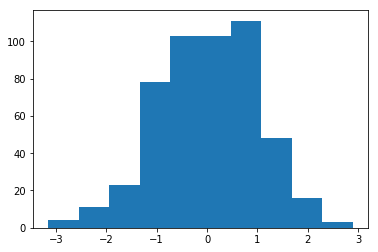

In [45]:
plt.hist(z_group["Age"])

In [46]:
fill_na_mean = lambda x : x.fillna(x.mean())

In [47]:
double_group.transform(fill_na_mean)

,Height,Weight,Age,Income
0,144.780663,44.257063,45.268935,163.468052
1,242.476989,48.426697,30.777017,180.521628
2,165.000476,58.397362,17.010116,188.199759
3,145.701341,69.220297,20.872532,224.261670
4,220.854182,101.566238,26.414266,120.782802
5,188.565246,71.544551,19.561617,112.662692
6,123.999344,113.800095,40.400033,149.314463
7,123.982691,49.684185,27.462232,171.061928
8,181.345714,44.277873,23.541646,149.337234
9,140.909250,71.243882,33.123424,181.301105


## Operaciones diversas muy útiles

In [48]:
double_group.head(1)

,Gender,Economic Status,Height,Weight,Age,Income
0,Female,Middle Class,144.780663,44.257063,45.268935,163.468052
1,Male,Rich,242.476989,48.426697,30.777017,180.521628
2,Male,Poor,165.000476,58.397362,17.010116,188.199759
3,Female,Rich,145.701341,69.220297,20.872532,224.261670
9,Male,Middle Class,140.909250,71.243882,33.123424,181.301105
14,Female,Poor,170.372345,58.800200,27.986508,145.001447


In [49]:
double_group.tail(1)

,Gender,Economic Status,Height,Weight,Age,Income
475,Male,Rich,160.125132,104.162119,13.153210,174.810939
489,Female,Rich,129.971624,41.896763,29.787591,146.620986
495,Female,Poor,117.511494,92.875392,26.474724,97.364477
497,Male,Poor,161.378407,64.404724,18.876860,130.600913
498,Female,Middle Class,181.399228,70.098744,28.452401,152.801711
499,Male,Middle Class,191.508520,74.198694,18.909557,126.131814


In [50]:
double_group.nth(32)

Age      Height      Income     Weight
Gender Economic Status                                              
Female Middle Class     21.348714  134.789378  196.972819  60.482798
       Poor             27.121117  171.066810  138.332424  50.897764
       Rich             47.986549  142.585223  122.159763  66.622665
Male   Middle Class     59.145265  119.234476  219.546433  54.250490
       Poor             35.279357  223.701673  155.837874  27.578064
       Rich              7.817299  175.936324  198.443680  47.860140

In [51]:
double_group.nth(82)

Age      Height      Income      Weight
Gender Economic Status                                               
Female Middle Class     61.881450  139.891659  152.007677   86.257571
Male   Poor             15.125673  162.463076  171.689261   46.114155
       Rich             13.153210  160.125132  174.810939  104.162119

In [52]:
data_sorted = data.sort_values(["Age", "Income"])

In [53]:
data_sorted.head(10)

,Gender,Economic Status,Height,Weight,Age,Income
487,Male,Poor,160.803985,73.597655,-11.871531,209.451377
360,Male,Poor,176.098775,94.049850,-5.581117,173.810624
178,Male,Poor,189.789824,44.977708,-3.266303,174.653612
354,Male,Rich,180.607517,31.494981,-3.043427,177.247916
392,Male,Poor,223.700372,39.552086,-2.108661,93.825590
476,Female,Poor,189.116435,90.004674,-1.135163,178.643890
390,Male,Middle Class,167.222027,67.955799,-1.117988,169.731197
186,Female,Middle Class,119.996763,121.878750,0.127232,124.631641
173,Female,Middle Class,135.754415,34.093128,0.550773,146.583115
339,Male,Rich,131.875919,91.672623,0.829395,115.897956


In [54]:
age_grouped = data_sorted.groupby("Gender")

In [56]:
age_grouped.head(1)

,Gender,Economic Status,Height,Weight,Age,Income
487,Male,Poor,160.803985,73.597655,-11.871531,209.451377
476,Female,Poor,189.116435,90.004674,-1.135163,178.643890


In [57]:
age_grouped.tail(1)

,Gender,Economic Status,Height,Weight,Age,Income
241,Male,Middle Class,119.234476,54.250490,59.145265,219.546433
494,Female,Middle Class,94.734354,35.219459,64.551524,128.422834
